In [1]:
from Bio.PDB import PDBParser, Superimposer, PDBIO
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 300
from scipy.spatial import distance
from tqdm import tqdm
from pymol import cmd
import numpy as np
import pandas as pd
import os

In [2]:
def get_sequence_length_in_pdb(pdb_file):
    # Initialize PDB parser
    parser = PDBParser(QUIET=True)

    # Parse the PDB file
    structure = parser.get_structure("structure", pdb_file)

    # Initialize variables to store chain information
    chain_lengths = {}

    # Iterate over chains in the first model
    for chain in structure[0]:
        chain_id = chain.id
        # Count residues in the chain
        residues = [res for res in chain if res.id[0] == " "]  # Exclude heteroatoms
        if len(residues) > 0:
            chain_lengths[chain_id] = len(residues)

    # Print the results
    # print(f"Number of chains: {len(chain_lengths)}")
    for k,v in chain_lengths.items():
        # print(k,v)
        pass
    if len(chain_lengths) > 1:
        raise ValueError("Multiple chains detected. It should only be one...")
    
    for chain_id, length in chain_lengths.items():
        return length

In [3]:
def align_structure(path_to_st1, path_to_st2):
    

    st1_name = os.path.basename(path_to_st1).split(".pdb")[0]
    st2_name = os.path.basename(path_to_st2).split(".pdb")[0]

    # Sequence lengths...
    n_res_1 = get_sequence_length_in_pdb(path_to_st1)
    n_res_2 = get_sequence_length_in_pdb(path_to_st2)
    # print("St1 length: ", n_res_1)
    # print("St2 length: ", n_res_2)

    # Define the residue range in st1
    df = pd.read_csv(os.path.join(root, "..", "processed", "trna_synthetases_data.csv"))
    st2 = os.path.basename(path_to_st2)
    start_residue = df[df["file_name"] == st2]["start_resid"].values[0]
    end_residue = df[df["file_name"] == st2]["end_resid"].values[0]
    # print(start_residue, end_residue)

    # Load the structures
    parser = PDBParser(QUIET=True)
    st1 = parser.get_structure(st1_name, path_to_st1)
    st2 = parser.get_structure(st2_name, path_to_st2)

    # Select Cα atoms from st1
    chain_id_ref = list(st1[0])[0].get_id()
    ref_atoms = [
        residue["CA"] for residue in st1[0][chain_id_ref]  # Notice that now the reference is not AlphaFill -chain_id may not necessarily be "A"
        if start_residue <= residue.id[1] <= end_residue
    ]

    # Select Cα atoms from the subset structure
    chain_id = list(st2[0])[0].get_id()
    # try:
    sample_atoms = [
        residue["CA"] for residue in st2[0][chain_id]
        if start_residue <= residue.id[1] <= end_residue
    ]
    # except:
    #     for residue in st2[0][chain_id]:
    #         print("Error!", residue)

    # print(len(ref_atoms), len(sample_atoms))

    # Perform the superimposition
    super_imposer = Superimposer()
    super_imposer.set_atoms(ref_atoms, sample_atoms)
    super_imposer.apply(st2.get_atoms())

    # Print the RMSD value
    # print(f"{st1_name} -- {st2_name} -- RMSD: {super_imposer.rmsÇ4f} Å")

    return round(super_imposer.rms, 2)

In [4]:
# Define paths
root = "."
aligned_dir = os.path.abspath(os.path.join(root, "..", "processed", "aligned_relaxed_structures"))
detected_pockets_dir = os.path.abspath(os.path.join(root, "..", "processed", "detected_pockets"))

# Pocket detection data
pocket_detection_data = pd.read_csv(os.path.join(root, "..", "processed", "pocket_detection_data.csv"))

# Get list of proteins
proteins = sorted(os.listdir(aligned_dir))

In [106]:
results = []

for protein in tqdm(proteins):

    # Get all structures
    sts = sorted(os.listdir(os.path.join(aligned_dir, protein)))

    # For each structure pair
    for c,st1 in enumerate(sts):
        for st2 in sts[c+1:]:
            
            #print(st1, st2)

            # Get pockets from st1 and st2
            pockets_st1 = pocket_detection_data[pocket_detection_data['File name'] == st1]
            pockets_st1 = {str(i): np.array(j.split(), dtype=float) for i,j in zip(pockets_st1['Pocket number'], pockets_st1['Pocket centroid coordinate (x y z)'])}
            pockets_st2 = pocket_detection_data[pocket_detection_data['File name'] == st2]
            pockets_st2 = {str(i): np.array(j.split(), dtype=float) for i,j in zip(pockets_st2['Pocket number'], pockets_st2['Pocket centroid coordinate (x y z)'])}

            if len(pockets_st1) > 0 and len(pockets_st2) > 0:

                # Align st1 and st2 - get RMSD
                path_to_st1 = os.path.join(aligned_dir, protein, st1)
                path_to_st2 = os.path.join(aligned_dir, protein, st2)
                rmsd = align_structure(path_to_st1, path_to_st2)

                # Pockets in st1
                for p1 in sorted(pockets_st1):
                    dists = [[protein, st1, p1, st2, p2, rmsd,
                            round(distance.euclidean(pockets_st1[p1], pockets_st2[p2]), 3)] for p2 in sorted(pockets_st2)]
                    minimum = sorted(dists, key=lambda x: x[6])[0]
                    results.append(minimum)

                # Pockets in st2
                for p2 in sorted(pockets_st2):
                    dists = [[protein, st2, p2, st1, p1, rmsd,
                            round(distance.euclidean(pockets_st1[p1], pockets_st2[p2]), 3)] for p1 in sorted(pockets_st1)]
                    minimum = sorted(dists, key=lambda x: x[6])[0]
                    results.append(minimum)

results = pd.DataFrame(results, columns=['Uniprot AC', 'File name 1', 'Pocket number 1', 'File name 2', 'Pocket number 2', 'RMSD' ,'Distance'])

100%|██████████| 21/21 [05:03<00:00, 14.43s/it]


In [107]:
print(f"Proteins: {len(set(results['Uniprot AC']))}")
print(f"Structures: {len(set(results['File name 1']).union(set(results['File name 2'])))}")
print(f"Structure pairs: {len(set([tuple([i,j]) for i,j in zip(results['File name 1'], results['File name 2'])]))}")
print(f"Pocket pairs: {len(set([tuple([i,j,k,l]) for i,j,k,l in zip(results['File name 1'], results['Pocket number 1'], results['File name 2'], results['Pocket number 2'])]))}")

Proteins: 21
Structures: 178
Structure pairs: 1566
Pocket pairs: 2523


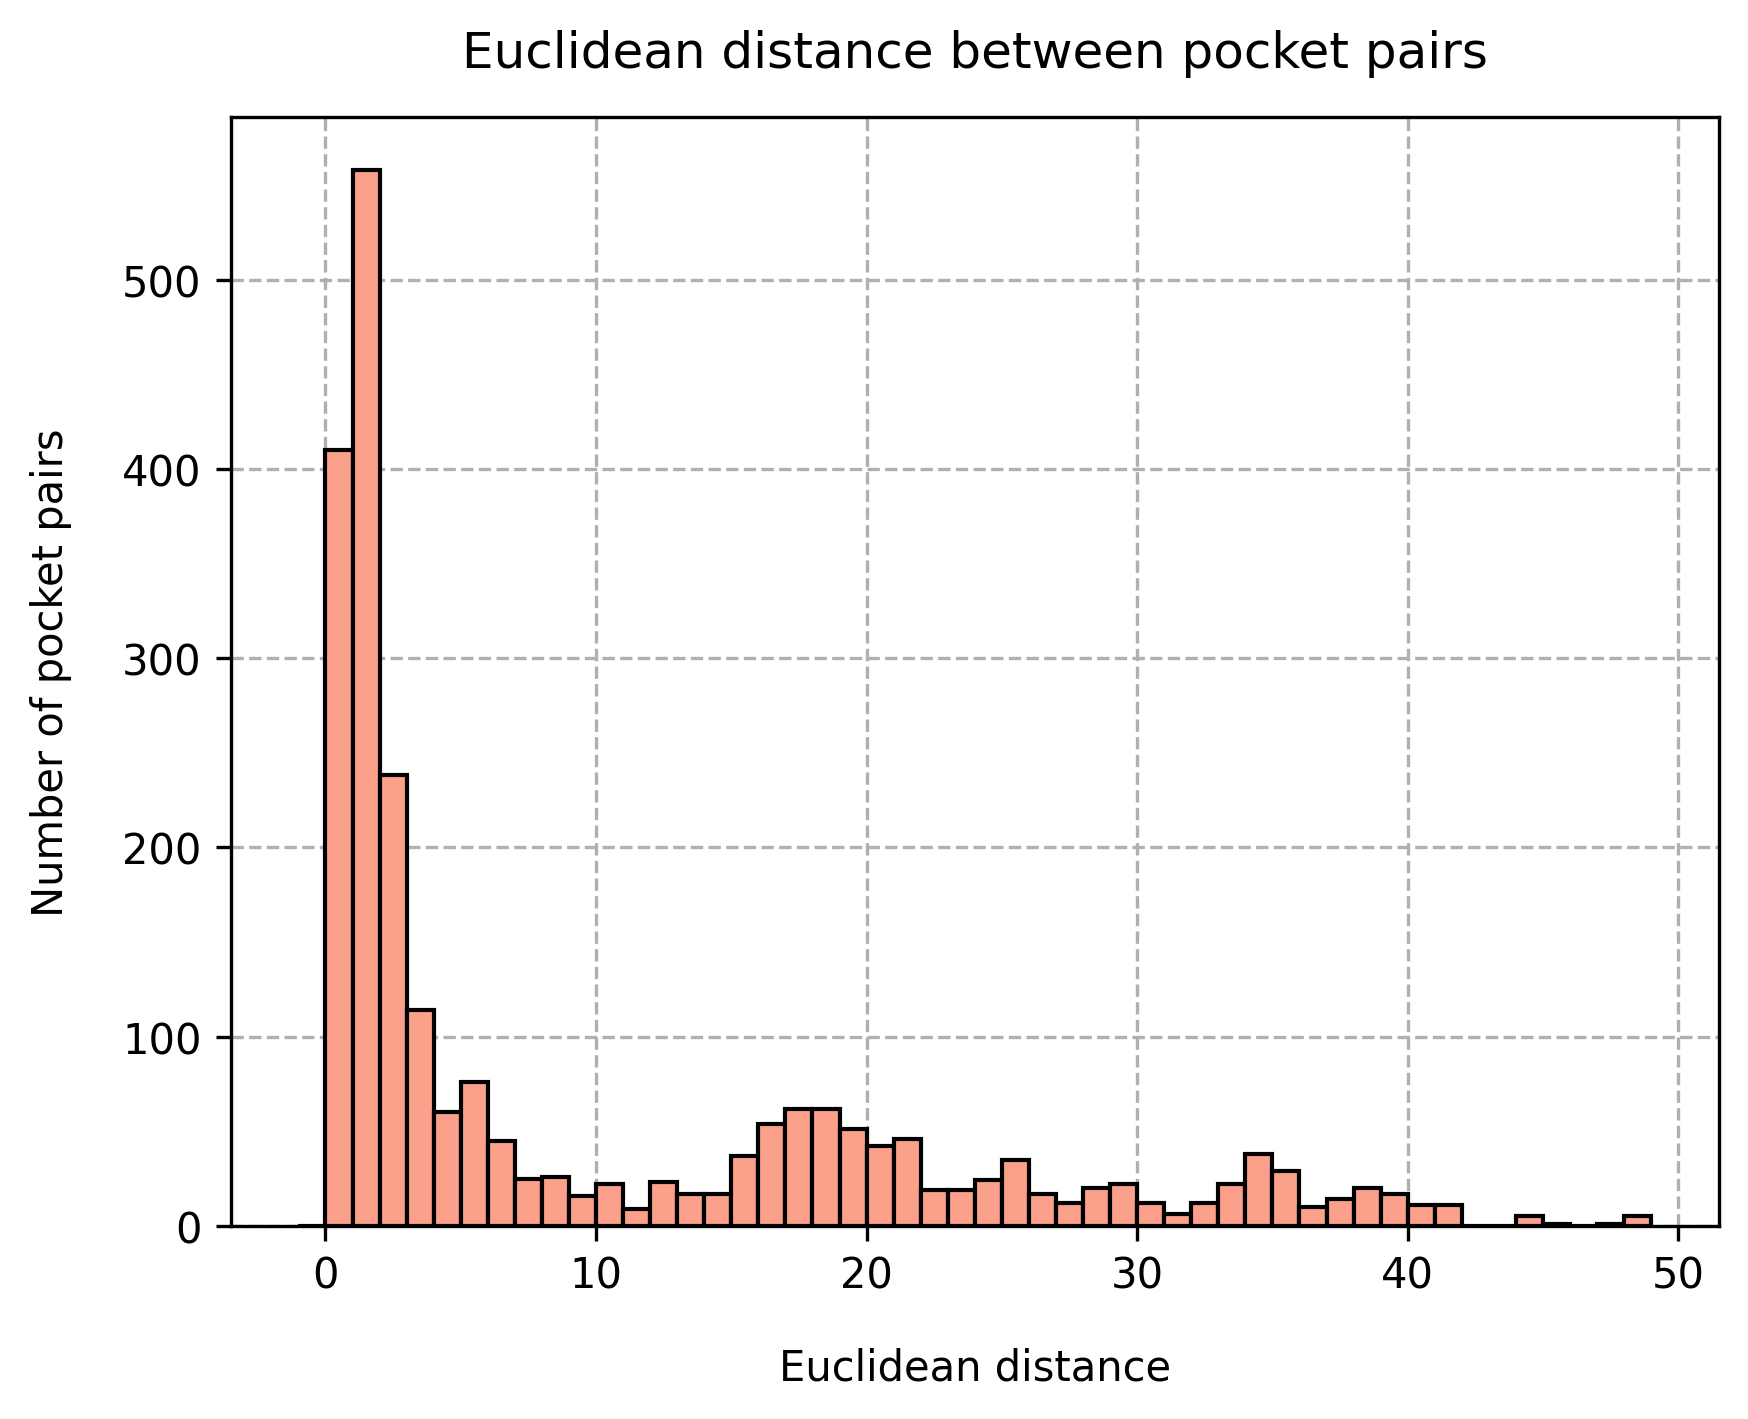

In [118]:
bins = [i for i in np.arange(-1, 50, 1)]
plt.hist(results['Distance'], bins=bins, edgecolor='k', zorder=2, color="#FAA08B")

plt.title("Euclidean distance between pocket pairs", pad=12)
plt.ylabel("Number of pocket pairs", labelpad=12)
plt.xlabel("Euclidean distance", labelpad=12)
plt.grid(linestyle='--', zorder=-2)
plt.show()

In [114]:
len(results[results['Distance'] < 6.14]) / len(results) * 100

58.10543004359889

In [127]:
rmsd_lim = 2
len(results[(results['Distance'] < 6.14) & (results['RMSD'] < rmsd_lim)]) / len(results[(results['RMSD'] < rmsd_lim)]) * 100

71.47435897435898